# CAMeLBERT-mix

In [21]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
import torch
print("="*50)
print("GPU CHECK")
print("="*50)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("WARNING: No GPU detected!")
    print("Go to Settings → Accelerator → Select 'GPU T4 x2'")
print("="*50)

GPU CHECK
CUDA available: True
Device count: 1
Current device: 0
Device name: Tesla P100-PCIE-16GB
CUDA version: 12.6


In [24]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

from datasets import Dataset, load_dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    cohen_kappa_score, 
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [25]:
MODEL_NAME = "CAMeL-Lab/bert-base-arabic-camelbert-mix"
path = "/kaggle/input/datasets/feryaljadallah/refinedbayyin/Refined_Bayyin_Dataset.csv"

In [26]:
OUTPUT_DIR_D3TOK = "/kaggle/working/runs/CAMeLBERT-mix_D3Tok"
SAVE_DIR_D3TOK = "/kaggle/working/CAMeLBERT-mix_D3Tok"

In [27]:
#Training parameters
LABEL_COL = "Readability_Level"
LEVELS = [1, 2, 3, 4, 5, 6]
LR = 5e-5
BATCH = 64
EPOCHS = 6
MAX_LEN = 128
SEED = 42
SOFT_BETA = 2.0

## Data Preparation

In [28]:
print("\nLoading dataset...")
dataset = load_dataset("csv", data_files={"train": path}, split="train")
print(f"Dataset columns: {dataset.column_names}")
print(f"Dataset size: {len(dataset)}")


Loading dataset...
Dataset columns: ['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex', 'Readability_Level', 'Document', 'Source', 'Book', 'Author', 'Domain', 'Text_Class', 'Dataset_Source']
Dataset size: 44917


In [29]:
required_columns = ["Word", "D3Tok", "Lex", "D3Lex", LABEL_COL]
missing = [col for col in required_columns if col not in dataset.column_names]
if missing:
    print(f"Missing columns: {missing}")

In [30]:
level2id = {lvl: i for i, lvl in enumerate(LEVELS)}
id2level = {i: lvl for lvl, i in level2id.items()}

def map_labels(ds):
    return ds.map(lambda ex: {"labels": level2id[int(ex[LABEL_COL])]})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [31]:
train_test = dataset.train_test_split(test_size=0.3, seed=SEED)
test_valid = train_test["test"].train_test_split(test_size=1/3, seed=SEED)
splits = DatasetDict({
    "train": train_test["train"],
    "test": test_valid["train"],
    "validation": test_valid["test"],
})
print(f"Train: {len(splits['train'])}, Test: {len(splits['test'])}, Val: {len(splits['validation'])}")

Train: 31441, Test: 8984, Val: 4492


## Model Training

In [32]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    return {"accuracy": acc, "macro_f1": macro_f1, "qwk": qwk}

In [33]:
class OrdinalAwareTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        probs = torch.softmax(logits, dim=-1)

        # HARD EXAMPLE WEIGHTING
        true_probs = probs.gather(1, labels.unsqueeze(1)).squeeze()

        # Hard sample → low confidence → high weight
        difficulty_weight = 1.0 - true_probs.detach()

        # Stabilize
        difficulty_weight = difficulty_weight + 0.5
        difficulty_weight = difficulty_weight / difficulty_weight.mean()

        # ORDINAL DISTANCE PENALTY
        K = logits.shape[-1]
        indices = torch.arange(K).float().to(logits.device)

        labels_float = labels.float().unsqueeze(1)
        dist = torch.abs(indices - labels_float)

        distance_penalty = torch.exp(-dist / 2.0)
        distance_penalty = distance_penalty / distance_penalty.sum(dim=1, keepdim=True)

        # BASE LOSS (Cross Entropy)
        ce_loss = F.cross_entropy(logits, labels, reduction="none")

        # APPLY WEIGHTS
        weighted_loss = ce_loss * difficulty_weight

        # Small ordinal regularization
        log_probs = F.log_softmax(logits, dim=-1)
        ordinal_loss = F.kl_div(log_probs, distance_penalty, reduction="none").sum(dim=1)

        final_loss = (weighted_loss + 0.4 * ordinal_loss).mean()

        return (final_loss, outputs) if return_outputs else final_loss

In [34]:
def eval_and_report(ds, name, trainer_obj):
    out = trainer_obj.predict(ds)
    preds = out.predictions.argmax(-1)
    print(f"\n{'='*60}")
    print(f"{name} Metrics")
    print('='*60)
    print(out.metrics)
    y_true = ds["labels"]
    target_names = [f"L{lvl}" for lvl in LEVELS]
    print("\nPer-class F1:")
    print(classification_report(y_true, preds, target_names=target_names, digits=4))

In [35]:
def plot_confusion_matrix_normalized(ds, trainer_obj, title_suffix="", normalize='true', cmap='Blues'):
    preds_output = trainer_obj.predict(ds)
    y_true = ds["labels"]
    y_pred = preds_output.predictions.argmax(-1)
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"{lvl}" for lvl in LEVELS])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=cmap, values_format=".2f", ax=ax, colorbar=True)
    plt.title(f"Normalized Confusion Matrix - {title_suffix}")
    plt.tight_layout()
    plt.show()

In [39]:
def train_model(text_col, output_dir, save_dir, model_name="Model"):
    print(f"\n{'#'*60}")
    print(f"# TRAINING MODEL: {model_name}")
    print(f"# Text Column: {text_col}")
    print(f"{'#'*60}\n")

    def tokenize_fn(batch):
        return tokenizer(batch[text_col], truncation=True, padding="max_length", max_length=MAX_LEN)
    
    train_ds = map_labels(splits["train"]).map(tokenize_fn, batched=True)
    val_ds = map_labels(splits["validation"]).map(tokenize_fn, batched=True)
    test_ds = map_labels(splits["test"]).map(tokenize_fn, batched=True)

    cols = ["input_ids", "attention_mask", "labels"]
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch", columns=cols)
    test_ds.set_format(type="torch", columns=cols)

    print(f"Loading model: {MODEL_NAME}")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(LEVELS))

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=LR,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model="qwk",
        greater_is_better=True,
        seed=SEED,
        report_to="none",
        save_total_limit=3,
        fp16=torch.cuda.is_available(),
    )

    trainer = OrdinalAwareTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    print(f"Starting Training for CAMeLBERT-mix for {EPOCHS} epochs...")
    trainer.train()

    print(f"\nSaving fine-tuned model to: {save_dir}")
    trainer.model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print("Model and tokenizer saved successfully!")

    print("\nEvaluating on Test Set...")
    eval_and_report(test_ds, f"Test (CAMeLBERT-mix - D3Tok)", trainer)
    plot_confusion_matrix_normalized(test_ds, trainer, title_suffix=model_name)

    return trainer, test_ds

In [37]:
def print_summary(results):
    """Print a comparison summary of all models"""
    print("\n" + "="*80)
    print("FINAL RESULTS SUMMARY - ALL MODELS")
    print("="*80)
    print(f"{'Model':<15} {'Accuracy':<12} {'Macro F1':<12} {'QWK':<12}")
    print("-"*80)
    
    for model_name, metrics in results.items():
        acc = metrics.get('eval_accuracy', 0)
        f1 = metrics.get('eval_macro_f1', 0)
        qwk = metrics.get('eval_qwk', 0)
        print(f"{model_name:<15} {acc:<12.4f} {f1:<12.4f} {qwk:<12.4f}")
    
    print("="*80)
    
    # Find best model for each metric
    best_acc = max(results.items(), key=lambda x: x[1].get('eval_accuracy', 0))
    best_f1 = max(results.items(), key=lambda x: x[1].get('eval_macro_f1', 0))
    best_qwk = max(results.items(), key=lambda x: x[1].get('eval_qwk', 0))
    
    print(f"\nBest Accuracy: {best_acc[0]} ({best_acc[1].get('eval_accuracy', 0):.4f})")
    print(f"Best Macro F1: {best_f1[0]} ({best_f1[1].get('eval_macro_f1', 0):.4f})")
    print(f"Best QWK: {best_qwk[0]} ({best_qwk[1].get('eval_qwk', 0):.4f})")
    print("="*80)

STARTING TRAINING PIPELINE - CAMeLBERT-msa

############################################################
# TRAINING MODEL: D3Tok
# Text Column: D3Tok
############################################################

Loading model: CAMeL-Lab/bert-base-arabic-camelbert-mix


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; n

Starting Training for CAMeLBERT-mix for 6 epochs...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk
1,1.247287,1.076716,0.754898,0.746238,0.842434
2,0.949244,0.998741,0.784728,0.782184,0.864687
3,0.755367,1.085297,0.782502,0.778403,0.877031
4,0.603747,1.183115,0.779831,0.776623,0.869676
5,0.514313,1.260453,0.785174,0.783129,0.874440
6,0.462557,1.306097,0.781389,0.779036,0.875850


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Saving fine-tuned model to: /kaggle/working/CAMeLBERT-mix_D3Tok


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully!

Evaluating on Test Set...



Test (CAMeLBERT-mix - D3Tok) Metrics
{'test_loss': 1.0842920541763306, 'test_accuracy': 0.7860641139804097, 'test_macro_f1': 0.7811691125895756, 'test_qwk': 0.8787948430672715, 'test_runtime': 31.9677, 'test_samples_per_second': 281.034, 'test_steps_per_second': 4.411}

Per-class F1:
              precision    recall  f1-score   support

          L1     0.7361    0.8170    0.7744      1519
          L2     0.7174    0.7657    0.7407      1528
          L3     0.7289    0.7990    0.7623      1353
          L4     0.7156    0.5567    0.6262      1437
          L5     0.8610    0.9275    0.8930      1530
          L6     0.9528    0.8355    0.8903      1617

    accuracy                         0.7861      8984
   macro avg     0.7853    0.7836    0.7812      8984
weighted avg     0.7888    0.7861    0.7842      8984



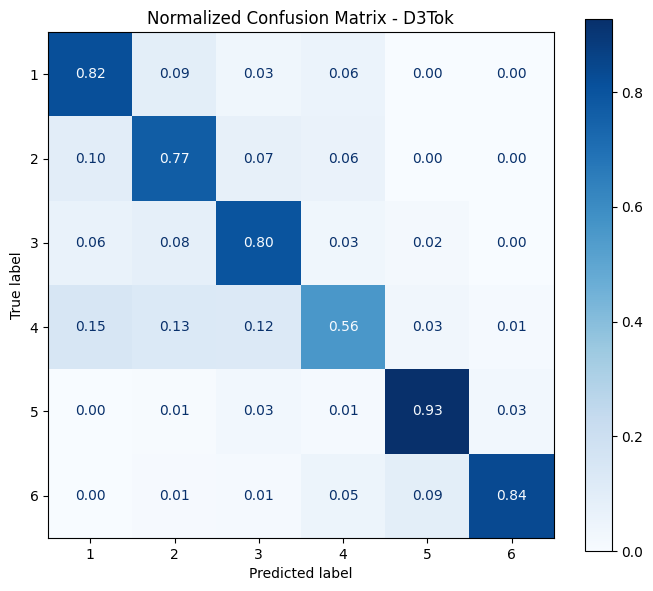


FINAL RESULTS SUMMARY - ALL MODELS
Model           Accuracy     Macro F1     QWK         
--------------------------------------------------------------------------------
D3Tok           0.7861       0.7812       0.8788      

Best Accuracy: D3Tok (0.7861)
Best Macro F1: D3Tok (0.7812)
Best QWK: D3Tok (0.8788)

ALL TRAINING COMPLETE!

Model saved to:
  - /kaggle/working/CAMeLBERT-mix_D3Tok



In [40]:
if __name__ == "__main__":
    results = {}
    print("STARTING TRAINING PIPELINE - CAMeLBERT-msa")

    # Train D3Tok
    trainer_d3tok, test_ds_d3tok = train_model("D3Tok", OUTPUT_DIR_D3TOK, SAVE_DIR_D3TOK, "D3Tok")
    results["D3Tok"] = trainer_d3tok.evaluate(test_ds_d3tok)

    # Summary
    print_summary(results)
    print("\n" + "="*80)
    print("ALL TRAINING COMPLETE!")
    print("="*80)
    print(f"\nModel saved to:\n  - {SAVE_DIR_D3TOK}\n")
    print("="*80)